In [29]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr

In [30]:
files = np.array(glob.glob("asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/*mrg60*R0.ict"))
print(len(files))
print(files)

25
['asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220716_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220901_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220718_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220813_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220913_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220825_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220829_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220821_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_20220909_R0.ict'
 'asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/ACCLIP-mrg60-WB57_merge_2022

In [92]:
for i,f in enumerate(files):
    date = f.split("_")[-2]
    col_header = np.char.strip(np.loadtxt(f, skiprows=302, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,3,4,5,6,13,19,22]))
    ll = np.loadtxt(f, skiprows=303, delimiter=",", usecols=[0,1,2,3,4,5,6,13,19,22])
    time = (ll[:,0] + ll[:,1])/2
    time_from_start = time - time[0]
    ds_f = xr.Dataset(
        data_vars=dict(
            lat=(["date","time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'LAT_GPS_MMS')[0][0]], axis=0)),
            lon=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'LON_GPS_MMS')[0][0]], axis=0)),
            alt=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'ALT_GPS_MMS')[0][0]], axis=0)),
            pres=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
            temp=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
            theta=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
            h2o_ChiWIS=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
            h2o_DLH=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_DLH')[0][0]], axis=0)),
        ),
        coords=dict(
            time_from_start=("time_from_start", time_from_start),
            date=[date],
        ),
    )
    if i == 0:
        ds = ds_f
    else:
        ds = xr.merge([ds, ds_f])

ds

<xarray.Dataset>
Dimensions:          (date: 25, time_from_start: 410)
Coordinates:
  * date             (date) <U8 '20220716' '20220718' ... '20220913' '20220914'
  * time_from_start  (time_from_start) float64 0.0 60.0 ... 2.448e+04 2.454e+04
Data variables:
    lat              (date, time_from_start) float64 29.58 29.58 ... nan nan
    lon              (date, time_from_start) float64 -95.15 -95.09 ... nan nan
    alt              (date, time_from_start) float64 757.5 1.683e+03 ... nan nan
    pres             (date, time_from_start) float64 936.1 841.0 ... nan nan
    temp             (date, time_from_start) float64 295.2 289.9 ... nan nan
    theta            (date, time_from_start) float64 300.9 304.6 ... nan nan
    h2o_ChiWIS       (date, time_from_start) float64 -1e+06 -1e+06 ... nan nan
    h2o_DLH          (date, time_from_start) float64 2.407e+04 1.691e+04 ... nan

20220716
duration =  5.1
altitude range =  9.77429 18.8674
theta range =  340.1272 445.0779
5.10 & 9.8 - 18.9 & 340.1 - 445.1

20220718
duration =  5.133333333333334
altitude range =  12.959299999999999 19.109599999999997
theta range =  350.669 445.1052
5.13 & 13.0 - 19.1 & 350.7 - 445.1

20220724
duration =  1.9833333333333334
altitude range =  8.67142 15.8617
theta range =  321.4791 426.8495
1.98 & 8.7 - 15.9 & 321.5 - 426.8

20220727
duration =  nan
altitude range =  nan nan
theta range =  nan nan
nan & nan - nan & nan - nan

20220802
duration =  3.533333333333333
altitude range =  14.7125 18.211299999999998
theta range =  359.3588 417.524
3.53 & 14.7 - 18.2 & 359.4 - 417.5

20220804
duration =  3.683333333333333
altitude range =  13.7317 18.5688
theta range =  355.2733 428.163
3.68 & 13.7 - 18.6 & 355.3 - 428.2

20220806
duration =  nan
altitude range =  nan nan
theta range =  nan nan
nan & nan - nan & nan - nan

20220812
duration =  4.633333333333334
altitude range =  10.2277 19.0

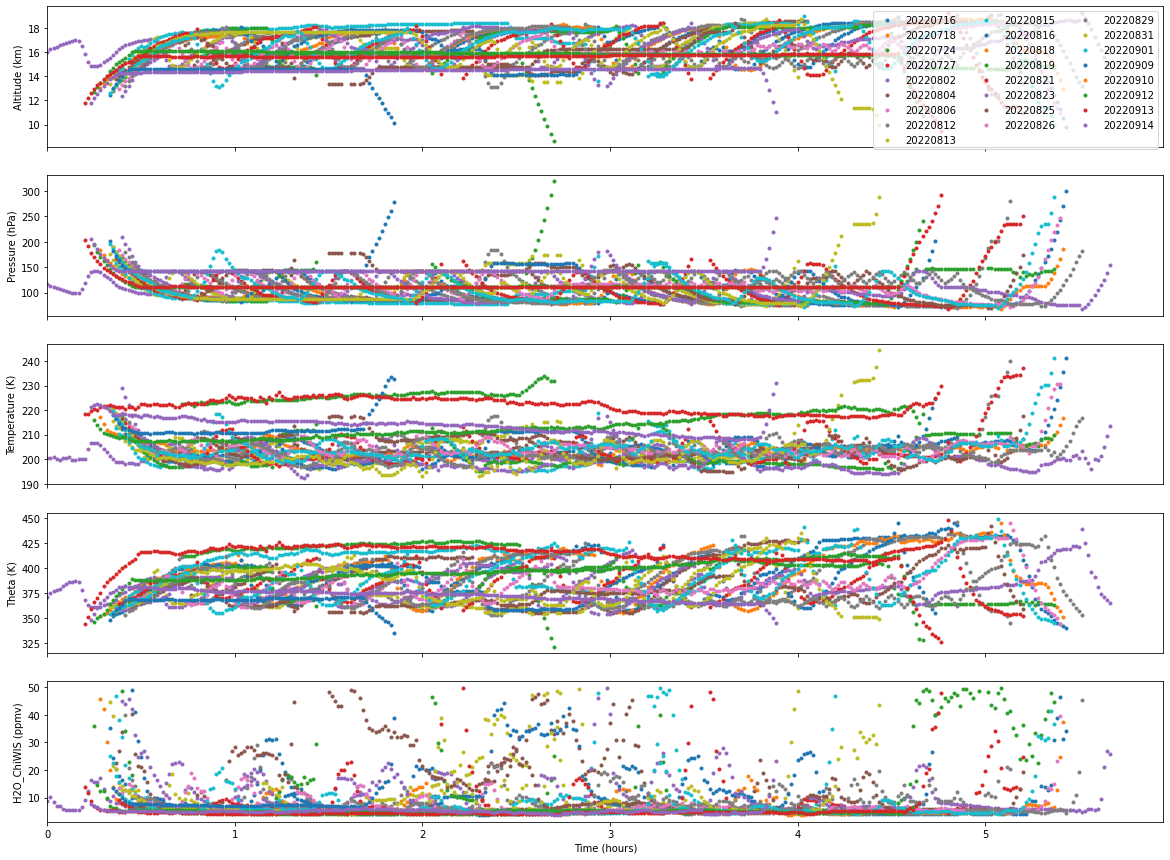

In [101]:
ds_sub100 = ds.where((ds.h2o_ChiWIS <= 100.0) & (ds.h2o_ChiWIS >= 0.1) & (ds.alt >= 1) )
ds_sub100

fig,axes = plt.subplots(5,1,figsize=(20,15),sharex=True)
for d in ds_sub100.date:
    di = ds_sub100.sel(date=d)
    time = (di.time_from_start) / 3600.
    axes[0].plot(time, di.alt / 1e3, '.', label=d.values)
    axes[1].plot(time, di.pres, '.', label=d.values)
    axes[2].plot(time, di.temp, '.', label=d.values)
    axes[3].plot(time, di.theta, '.', label=d.values)
    axes[4].plot(time, di.h2o_ChiWIS, '.', label=d.values)
    
    print(d.values)
    duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
    print("duration = ", duration.values / 3600.)
    print("altitude range = ", di.alt.min().values / 1e3, di.alt.max().values / 1e3)
    print("theta range = ", di.theta.min().values, di.theta.max().values)
    print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e3:.1f} - {di.alt.max().values / 1e3:.1f} & {di.theta.min().values:.1f} - {di.theta.max().values:.1f}")
    print()

axes[0].legend(ncol=3, loc=1)
axes[0].set_ylabel("Altitude (km)")
axes[1].set_ylabel("Pressure (hPa)")
axes[2].set_ylabel("Temperature (K)")
axes[3].set_ylabel("Theta (K)")
axes[4].set_ylabel("H2O_ChiWIS (ppmv)")

axes[4].set_xlim(0)
axes[4].set_xlabel("Time (hours)")

plt.show()

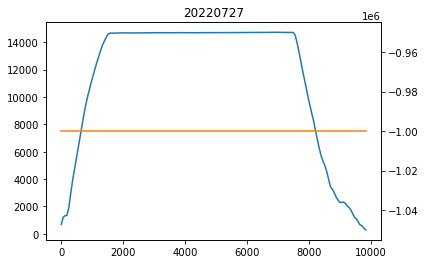

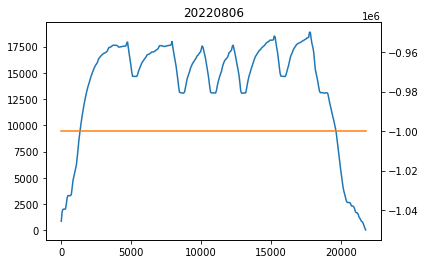

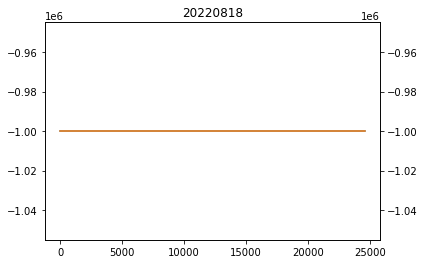

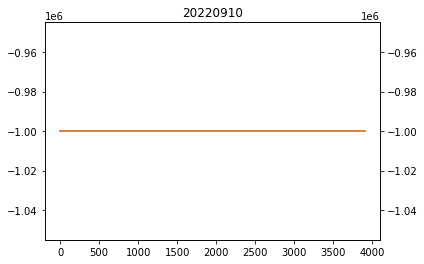

In [120]:
di = ds.sel(date="20220727")
plt.plot(di.time_from_start, di.alt)
plt.twinx().plot(di.time_from_start, di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

di = ds.sel(date="20220806")
plt.plot(di.time_from_start, di.alt)
plt.twinx().plot(di.time_from_start, di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

di = ds.sel(date="20220818")
plt.plot(di.time_from_start, di.alt)
plt.twinx().plot(di.time_from_start, di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

di = ds.sel(date="20220910")
plt.plot(di.time_from_start, di.alt)
plt.twinx().plot(di.time_from_start, di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

In [131]:
path = "asdc.larc.nasa.gov/data/ACCLIP/Merge_WB57-Aircraft_Data_1/"
files = np.array([path+"ACCLIP-mrg60-WB57_merge_20220721_RH.ict", path+"ACCLIP-mrg60-WB57_merge_20220725_RH.ict"])

for i,f in enumerate(files):
    date = f.split("_")[-2]
    print(date)
    col_header = np.char.strip(np.loadtxt(f, skiprows=309, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,3,4,5,6,13,19,22]))
    print(col_header)
    ll = np.loadtxt(f, skiprows=310, delimiter=",", usecols=[0,1,2,3,4,5,6,13,19,22])
    time = (ll[:,0] + ll[:,1])/2
    time_from_start = time - time[0]
    ds_f = xr.Dataset(
        data_vars=dict(
            lat=(["date","time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'LAT_GPS_MMS')[0][0]], axis=0)),
            lon=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'LON_GPS_MMS')[0][0]], axis=0)),
            alt=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'ALT_GPS_MMS')[0][0]], axis=0)),
            pres=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
            temp=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
            theta=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
            h2o_ChiWIS=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
            h2o_DLH=(["date", "time_from_start"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_DLH')[0][0]], axis=0)),
        ),
        coords=dict(
            time_from_start=("time_from_start", time_from_start),
            date=[date],
        ),
    )
    if i == 0:
        dsRH = ds_f
    else:
        dsRH = xr.merge([dsRH, ds_f])

dsRH

20220721
['Time_Start' 'Time_Stop' 'LAT_GPS_MMS' 'LON_GPS_MMS' 'ALT_GPS_MMS'
 'P_MMS' 'T_MMS' 'POT_MMS' 'H2O_DLH' 'H2O_ChiWIS']
20220725
['Time_Start' 'Time_Stop' 'LAT_GPS_MMS' 'LON_GPS_MMS' 'ALT_GPS_MMS'
 'P_MMS' 'T_MMS' 'POT_MMS' 'H2O_DLH' 'H2O_ChiWIS']


<xarray.Dataset>
Dimensions:          (date: 2, time_from_start: 667)
Coordinates:
  * date             (date) <U8 '20220721' '20220725'
  * time_from_start  (time_from_start) float64 0.0 60.0 ... 3.99e+04 3.996e+04
Data variables:
    lat              (date, time_from_start) float64 29.58 29.57 ... nan nan
    lon              (date, time_from_start) float64 -95.13 -95.08 ... nan nan
    alt              (date, time_from_start) float64 815.9 1.772e+03 ... nan nan
    pres             (date, time_from_start) float64 926.6 830.0 ... nan nan
    temp             (date, time_from_start) float64 296.4 292.6 ... nan nan
    theta            (date, time_from_start) float64 303.0 308.6 ... nan nan
    h2o_ChiWIS       (date, time_from_start) float64 -1e+06 -1e+06 ... nan nan
    h2o_DLH          (date, time_from_start) float64 2.031e+04 1.128e+04 ... nan

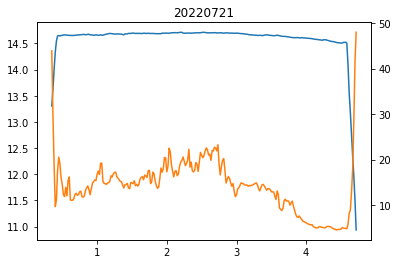

20220721
duration =  4.366666666666666
altitude range =  10.937 14.7134
theta range =  336.3224 376.4971
4.37 & 10.9 - 14.7 & 336.3 - 376.5



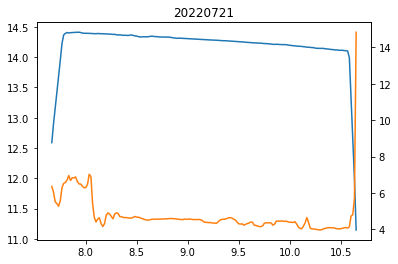

20220721
duration =  2.9833333333333334
altitude range =  11.1479 14.4105
theta range =  341.7642 392.4511
2.98 & 11.1 - 14.4 & 341.8 - 392.5



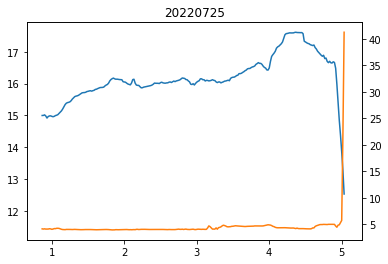

20220725
duration =  4.2
altitude range =  11.402299999999999 17.6146
theta range =  345.018 423.2089
4.20 & 11.4 - 17.6 & 345.0 - 423.2



In [142]:
di = dsRH.sel(date="20220721")
di = di.where((di.alt >= 1) & (di.h2o_ChiWIS > 0) & (di.h2o_ChiWIS <= 100))
di = di.where(di.time_from_start < 22000)
plt.plot(di.time_from_start / 3600., di.alt / 1e3)
plt.twinx().plot(di.time_from_start / 3600., di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

print(di.date.values)
duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
print("duration = ", duration.values / 3600.)
print("altitude range = ", di.alt.min().values / 1e3, di.alt.max().values / 1e3)
print("theta range = ", di.theta.min().values, di.theta.max().values)
print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e3:.1f} - {di.alt.max().values / 1e3:.1f} & {di.theta.min().values:.1f} - {di.theta.max().values:.1f}")
print()

di = dsRH.sel(date="20220721")
di = di.where((di.alt >= 1) & (di.h2o_ChiWIS > 0) & (di.h2o_ChiWIS <= 100))
di = di.where(di.time_from_start > 22000)
plt.plot(di.time_from_start / 3600., di.alt / 1e3)
plt.twinx().plot(di.time_from_start / 3600., di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

print(di.date.values)
duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
print("duration = ", duration.values / 3600.)
print("altitude range = ", di.alt.min().values / 1e3, di.alt.max().values / 1e3)
print("theta range = ", di.theta.min().values, di.theta.max().values)
print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e3:.1f} - {di.alt.max().values / 1e3:.1f} & {di.theta.min().values:.1f} - {di.theta.max().values:.1f}")
print()

di = dsRH.sel(date="20220725")
di = di.where((di.alt >= 1) & (di.h2o_ChiWIS > 0) & (di.h2o_ChiWIS <= 100))
plt.plot(di.time_from_start / 3600., di.alt / 1e3)
plt.twinx().plot(di.time_from_start / 3600., di.h2o_ChiWIS, color="C1")
plt.title(di.date.values)
plt.show()

print(di.date.values)
duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
print("duration = ", duration.values / 3600.)
print("altitude range = ", di.alt.min().values / 1e3, di.alt.max().values / 1e3)
print("theta range = ", di.theta.min().values, di.theta.max().values)
print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e3:.1f} - {di.alt.max().values / 1e3:.1f} & {di.theta.min().values:.1f} - {di.theta.max().values:.1f}")
print()